In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [1]:
!make

make: *** No targets specified and no makefile found.  Stop.


In [4]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [ ]:
n_runs = 1000

# Single threaded tests

## Pop back

[array([1820, 1690, 1687, 1643, 1661, 1615, 1593, 1589, 1614, 1617, 1583,
       1592, 1686, 1585, 1576, 1603, 1571, 1575, 1607, 1576, 1586, 1589,
       1577, 1579, 1575, 1572, 1584, 1577, 1578, 1579, 1576, 1601, 1731,
       1587, 1585, 1612, 1578, 1573, 1619, 1575, 1574, 1578, 1578, 1646,
       1574, 1574, 1572, 1689, 2563, 1693, 1698, 1701, 1695, 1831, 1685,
       1580, 1629, 1675, 1571, 1576, 1567, 1650, 1734, 1589, 1576, 1615,
       1689, 1578, 1619, 1578, 1601, 1615, 1594, 1591, 1594, 1573, 1585,
       1639, 1577, 1576, 1577, 1624, 1567, 1574, 1715, 1680, 1630, 1685,
       1639, 1633, 1619, 1574, 1574, 1583, 1577, 1573, 1579, 1562, 1578,
       1650, 1603, 1575, 1578, 1590, 1577, 1613, 1656, 1584, 1639, 1577,
       1563, 1604, 1577, 1574, 1575, 1575, 1583, 1574, 1611, 1600, 1712,
       1777, 1673, 1648, 1629, 1623, 1639, 1576, 1575, 1582, 1577, 1576,
       1611, 1577, 1575, 1616, 1582, 1579, 1713, 1689, 1687, 1645, 1753,
       1631, 1630, 1608, 1587, 1576, 1599, 1584, 1

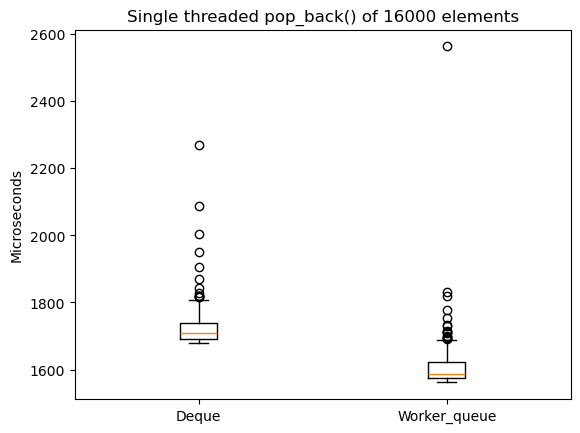

In [6]:
test_worker_queue_pop_back = run_test("test_worker_queue_pop_back",n_runs,16000)
test_deque_pop_back = run_test("test_deque_pop_back",n_runs,16000)


fig, ax = plt.subplots()

ax.boxplot([test_deque_pop_back[0],test_worker_queue_pop_back[0]], positions=[1,2])
# Etichette per gli assi
ax.set_xticks([1,2],["Deque","Worker_queue"])
ax.set(ylabel = 'Microseconds')
ax.set(title = 'Single threaded pop_back() of 16000 elements')

plt.show()



## Pop front

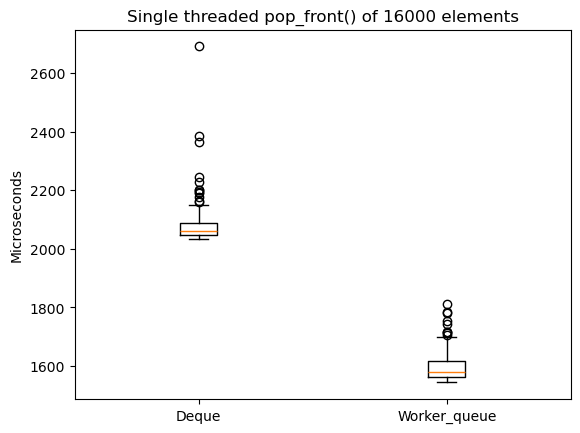

In [9]:
test_worker_queue_pop_front = run_test("test_worker_queue_pop_front",n_runs,16000)
test_deque_pop_front = run_test("test_deque_pop_front",n_runs,16000)

fig, ax = plt.subplots()

ax.boxplot([test_deque_pop_front[0],test_worker_queue_pop_front[0]], positions=[1,2])
# Etichette per gli assi
ax.set_xticks([1,2],["Deque","Worker_queue"])
ax.set(ylabel = 'Microseconds')
ax.set(title = 'Single threaded pop_front() of 16000 elements')

plt.show()

## Push back

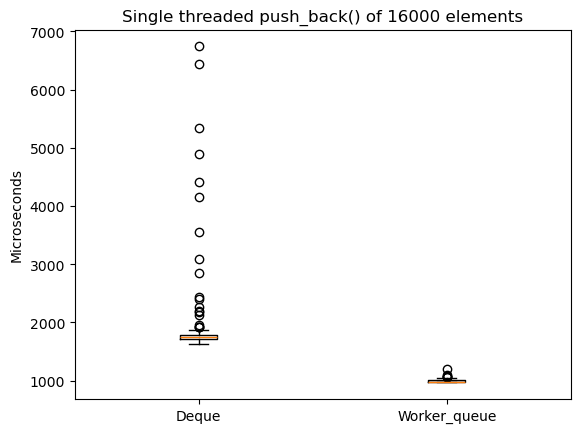

In [106]:
test_worker_queue_push_back = run_test("test_worker_queue_push_back",n_runs,16000)
test_deque_push_back = run_test("test_deque_push_back",n_runs,16000)

fig, ax = plt.subplots()

ax.boxplot([test_deque_push_back[0],test_worker_queue_push_back[0]], positions=[1,2])
# Etichette per gli assi
ax.set_xticks([1,2],["Deque","Worker_queue"])
ax.set(ylabel = 'Microseconds')
ax.set(title = 'Single threaded push_back() of 16000 elements')

plt.show()

## Push front

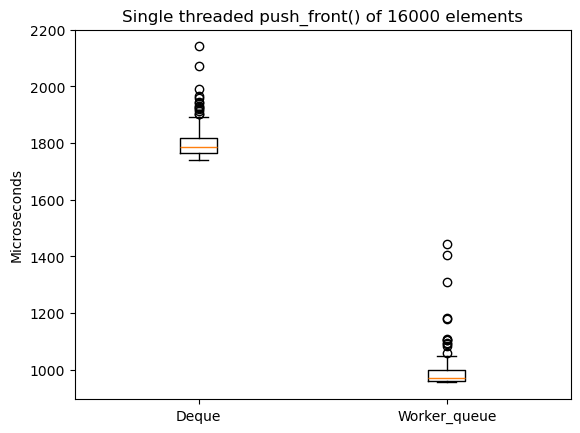

In [107]:
test_worker_queue_push_front = run_test("test_worker_queue_push_front",n_runs,16000)
test_deque_push_front = run_test("test_deque_push_front",n_runs,16000)

fig, ax = plt.subplots()

ax.boxplot([test_deque_push_front[0],test_worker_queue_push_front[0]], positions=[1,2])
# Etichette per gli assi
ax.set_xticks([1,2],["Deque","Worker_queue"])
ax.set(ylabel = 'Microseconds')
ax.set(title = 'Single threaded push_front() of 16000 elements')

plt.show()

# Multithreaded tests

## Pop back

In [10]:
test_deque = run_test("test_deque_pop_back_multi",n_runs,16000,[2,4,6,8])
test_worker_queue = run_test("test_worker_queue_pop_back_multi",n_runs,16000,[2,4,6,8])

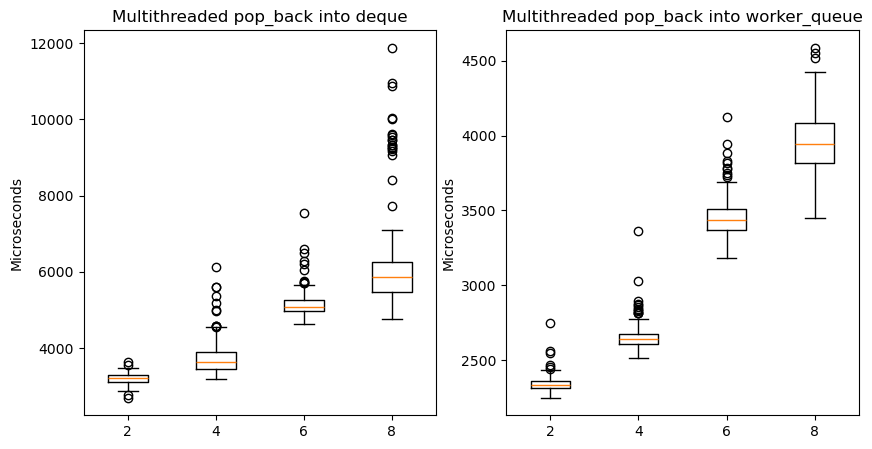

In [11]:

fig, ax = plt.subplots(figsize=[10, 5])

boxes = []

for i in range(0,size(test_deque)):
    boxes.append(test_deque[i])
    boxes.append(test_worker_queue[i])



ax.boxplot(test_deque)
# Etichette per gli assi
ax.set_xticks([1,2,3,4],["2","4","6","8"])
ax.set(ylabel = 'Microseconds')
ax.set(title = 'Multithreaded pop_back into deque')

plt.show()


## Pop front

In [12]:
test_deque = run_test("test_deque_pop_front_multi",n_runs,16000,[2,4,6,8])
test_worker_queue = run_test("test_worker_queue_pop_front_multi",n_runs,16000,[2,4,6,8])

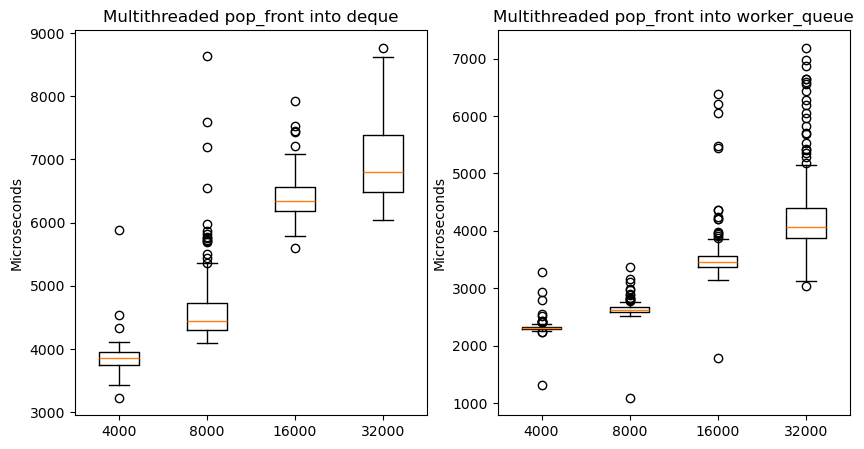

In [13]:
fig, ax = plt.subplots(1,2,figsize=[10, 5])

ax[0].boxplot(test_deque)
# Etichette per gli assi
ax[0].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[0].set(ylabel = 'Microseconds')
ax[0].set(title = 'Multithreaded pop_front into deque')

ax[1].boxplot(test_worker_queue)
# Etichette per gli assi
ax[1].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[1].set(ylabel = 'Microseconds')
ax[1].set(title = 'Multithreaded pop_front into worker_queue')

plt.show()

## Push back

In [14]:
test_deque = run_test("test_deque_push_back_multi",n_runs,16000,[2,4,6,8])
test_worker_queue = run_test("test_worker_queue_push_back_multi",n_runs,16000,[2,4,6,8])

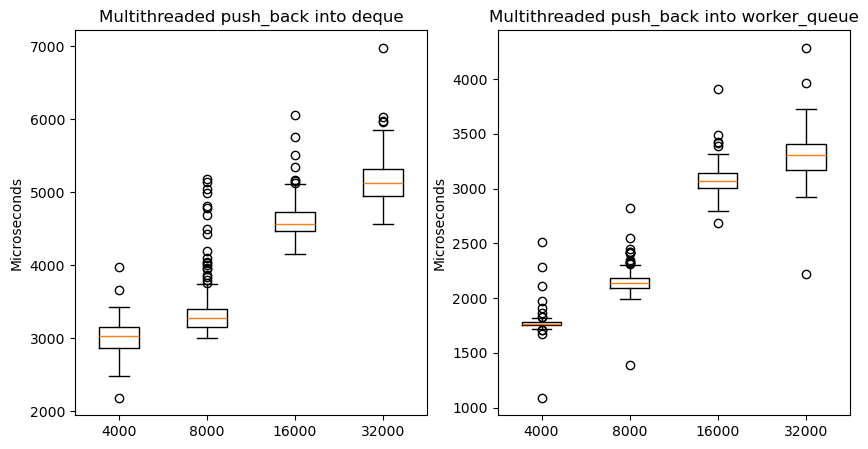

In [15]:
fig, ax = plt.subplots(1,2,figsize=[10, 5])

ax[0].boxplot(test_deque)
# Etichette per gli assi
ax[0].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[0].set(ylabel = 'Microseconds')
ax[0].set(title = 'Multithreaded push_back into deque')

ax[1].boxplot(test_worker_queue)
# Etichette per gli assi
ax[1].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[1].set(ylabel = 'Microseconds')
ax[1].set(title = 'Multithreaded push_back into worker_queue')

plt.show()

## Push front

In [16]:
test_deque = run_test("test_deque_push_front_multi",n_runs,16000,[2,4,6,8])
test_worker_queue = run_test("test_worker_queue_push_front_multi",n_runs,16000,[2,4,6,8])

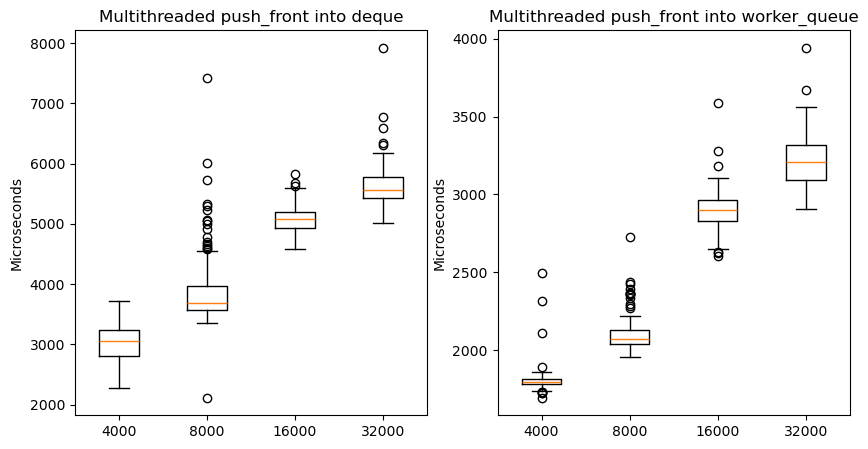

In [17]:
fig, ax = plt.subplots(1,2,figsize=[10, 5])

ax[0].boxplot(test_deque)
# Etichette per gli assi
ax[0].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[0].set(ylabel = 'Microseconds')
ax[0].set(title = 'Multithreaded push_front into deque')

ax[1].boxplot(test_worker_queue)
# Etichette per gli assi
ax[1].set_xticks([1,2,3,4],["4000","8000","16000","32000"])
ax[1].set(ylabel = 'Microseconds')
ax[1].set(title = 'Multithreaded push_front into worker_queue')

plt.show()